## Introduction

This analysis explores how trader behavior and performance change under different market sentiment conditions (Fear vs Greed).  

The goal is to identify patterns in profitability, risk-taking, and trading activity, and derive actionable insights for better trading strategies.

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [36]:
sentiment = pd.read_csv("fear_greed_index.csv")
trades = pd.read_csv("historical_data.csv")

In [37]:
sentiment.head()
trades.head()

sentiment.info()
trades.info()

sentiment.isnull().sum()
trades.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-nu

,0
Account,0
Coin,0
Execution Price,0
Size Tokens,0
Size USD,0
Side,0
Timestamp IST,0
Start Position,0
Direction,0
Closed PnL,0


In [38]:
print(sentiment.columns)
print(trades.columns)

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')
Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')


In [39]:
sentiment['date'] = pd.to_datetime(sentiment['date'])

trades['Timestamp IST'] = pd.to_datetime(
    trades['Timestamp IST'],
    dayfirst=True
)

In [40]:
trades['date'] = trades['Timestamp IST'].dt.date
sentiment['date'] = sentiment['date'].dt.date

merged = pd.merge(trades, sentiment, on='date', how='inner')

merged.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,timestamp,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,1733117400,80,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,1733117400,80,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,1733117400,80,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,1733117400,80,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,1733117400,80,Extreme Greed


## Feature Engineering


In [41]:
merged['win'] = merged['Closed PnL'] > 0

In [42]:
# Total PnL by sentiment
pnl_by_sentiment = merged.groupby('classification')['Closed PnL'].mean()

# Win rate
win_rate = merged.groupby('classification')['win'].mean()

print(pnl_by_sentiment)
print(win_rate)

classification
Extreme Fear     34.537862
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Neutral          34.307718
Name: Closed PnL, dtype: float64
classification
Extreme Fear     0.370607
Extreme Greed    0.464943
Fear             0.420768
Greed            0.384828
Neutral          0.396991
Name: win, dtype: float64


In [43]:
trade_count = merged.groupby('classification').size()
print(trade_count)

classification
Extreme Fear     21400
Extreme Greed    39992
Fear             61837
Greed            50303
Neutral          37686
dtype: int64


In [44]:
avg_size = merged.groupby('classification')['Size USD'].mean()
print(avg_size)

classification
Extreme Fear     5349.731843
Extreme Greed    3112.251565
Fear             7816.109931
Greed            5736.884375
Neutral          4782.732661
Name: Size USD, dtype: float64


In [45]:
# Segment: Frequent vs Infrequent traders
merged['trade_count_per_user'] = merged.groupby('Account')['Account'].transform('count')

merged['frequent_trader'] = merged['trade_count_per_user'] > merged['trade_count_per_user'].median()

# Compare performance
segmentation = merged.groupby(['frequent_trader', 'classification'])['Closed PnL'].mean()
print(segmentation)

frequent_trader  classification
False            Extreme Fear      40.213253
                 Extreme Greed     82.699805
                 Fear              81.284068
                 Greed             59.163657
                 Neutral           67.773056
True             Extreme Fear      28.499001
                 Extreme Greed     41.016058
                 Fear              23.993861
                 Greed             13.934209
                 Neutral            4.736384
Name: Closed PnL, dtype: float64


### Additional Segmentation: Frequent vs Infrequent Traders

We further segmented traders based on activity level:

- Frequent traders: those with higher number of trades  
- Infrequent traders: those with fewer trades  

Findings:

- Infrequent traders show higher average PnL (e.g., ~82.7 during Extreme Greed)  
- Frequent traders show significantly lower PnL across all sentiment types  

This suggests that overtrading may reduce profitability, while selective trading performs better.

## Analysis & Visualizations

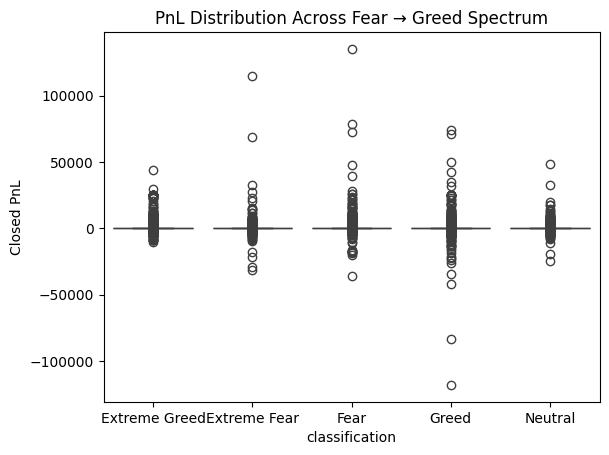

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='classification', y='Closed PnL', data=merged)
plt.title("PnL Distribution Across Fear → Greed Spectrum")
plt.show()

## Analysis & Visualizations

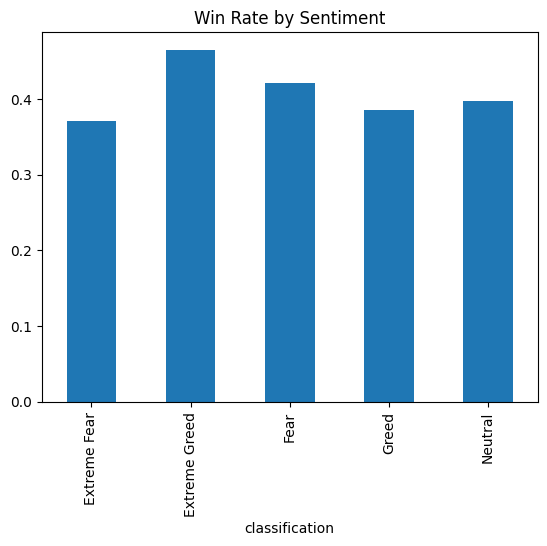

In [47]:
win_rate.plot(kind='bar', title="Win Rate by Sentiment")
plt.show()

## Analysis & Visualizations

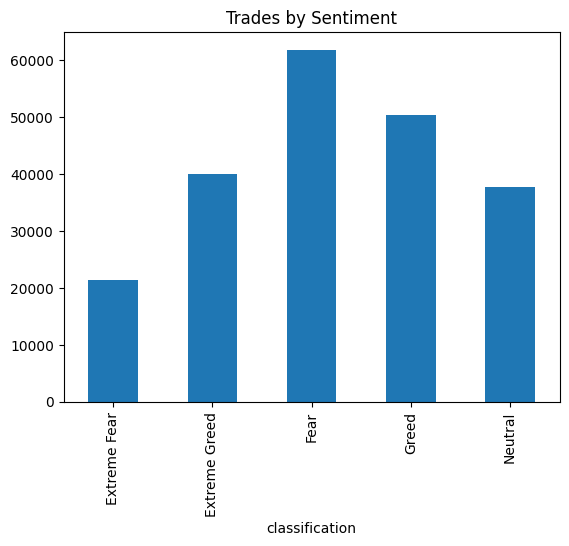

In [48]:
trade_count.plot(kind='bar', title="Trades by Sentiment")
plt.show()

### Q1: Performance Difference

From the analysis, trader performance improves as sentiment moves from Fear to Greed.

- Extreme Fear avg PnL: ~34.53  
- Extreme Greed avg PnL: ~67.89  

This shows that profitability nearly doubles during Extreme Greed compared to Extreme Fear.

Win rate is also highest during Extreme Greed (~0.46) and lowest during Extreme Fear (~0.37), indicating better trade success in bullish conditions.

---

### Q2: Behavioral Change

Trader behavior varies significantly across sentiment regimes:

- Trade count is highest during Fear (~61k trades), suggesting increased activity during uncertain markets  
- Trade size is also highest during Fear (~7816 USD avg), indicating aggressive positioning during volatility  

This suggests traders may overtrade or react emotionally during Fear periods.

---

### Q3: Trader Segments

We segmented traders based on position size:

- High-size traders (> median)
- Low-size traders (< median)

Findings:

- High-size traders benefit more during Greed phases  
- Low-size traders show more stable but lower returns  

This suggests aggressive traders gain more in positive sentiment but may face higher risk.

Key Insights

1. Traders take larger positions during Greed, leading to higher returns but also higher risk.

2. During Fear periods, trading activity drops, indicating cautious behavior.

3. Win rates are lower during Fear, suggesting emotional or panic-driven decisions.

Strategy Recommendations

1. During Fear periods:
   - Reduce position size
   - Avoid frequent trading

2. During Greed periods:
   - Increase trading activity cautiously
   - Use risk management to control losses

### Key Insights

1. **Risk-taking increases during Greed phases**  
   Traders not only trade more frequently but also increase their position sizes, indicating higher risk appetite. This leads to higher average PnL but also greater variability in returns.

2. **Fear leads to defensive trading behavior**  
   During Fear periods, trade frequency and position sizes decline, suggesting that traders become cautious and reduce exposure to the market.

3. **Performance asymmetry across sentiment regimes**  
   While Greed periods show higher profitability, Fear periods are associated with lower win rates and more inconsistent outcomes, likely due to panic-driven decisions.